In [ ]:
import torch
import torchvision
import torch.nn.functional as F
from torch.utils.data.dataloader import DataLoader
from torch import nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torcheval.metrics.functional import multiclass_f1_score, multiclass_precision, multiclass_recall, r2_score, mean_squared_error
import matplotlib.pyplot as plt


In [84]:
# Второй датасет

In [85]:
df = pd.read_excel("../lessons/Concrete_Data.xls")

In [86]:
df.columns = df.columns.str.strip()
X = df.drop(['Concrete compressive strength(MPa, megapascals)'], axis=1)
y = df[['Concrete compressive strength(MPa, megapascals)']]

In [87]:
num_features = X.shape[1]

In [88]:
X_tensor = torch.tensor(X.values).float()
y_tensor = torch.tensor(y.values).float().reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

scaler_classifier = StandardScaler()
x_train_scaled = scaler_classifier.fit_transform(X_train)
x_test_scaled = scaler_classifier.transform(X_test)

y_train_scaled = scaler_classifier.fit_transform(y_train)
y_test_scaled = scaler_classifier.transform(y_test)

X_train = torch.tensor(x_train_scaled).float()
X_test = torch.tensor(x_test_scaled).float()

y_train = torch.tensor(y_train_scaled).float()
y_test = torch.tensor(y_test_scaled).float()

train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
test_dataset = torch.utils.data.TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

In [89]:
class SimpleRegressionModel(nn.Module):
    def __init__(self, input_size):
        super(SimpleRegressionModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)
        return out

model = SimpleRegressionModel(num_features)

In [90]:
num_epochs = 100
lr = 0.001

In [91]:
def train_model(model, train_loader, criterion, optimizer):
    model.train()
    train_losses = []
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"Эпоха {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}")
    
    return train_losses

def evaluate_model(model, test_loader):
    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        r2 = r2_score(outputs, y_test)
        mse = mean_squared_error(outputs, y_test)
    print(f"R2: {r2.item():.4f}")
    print(f"MSE: {mse.item():.4f}")



Эпоха 10/100, Loss: 0.192122
Эпоха 20/100, Loss: 0.121287
Эпоха 30/100, Loss: 0.089417
Эпоха 40/100, Loss: 0.075947
Эпоха 50/100, Loss: 0.062820
Эпоха 60/100, Loss: 0.058442
Эпоха 70/100, Loss: 0.050666
Эпоха 80/100, Loss: 0.045723
Эпоха 90/100, Loss: 0.047829
Эпоха 100/100, Loss: 0.043316
R2: 0.8820
MSE: 0.1070


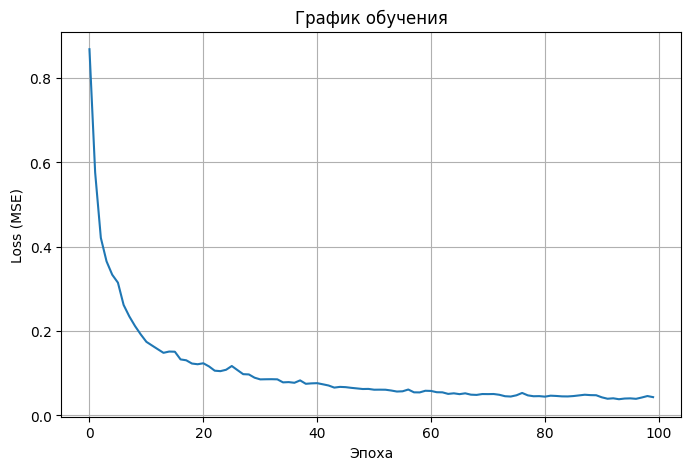

In [92]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr)

train_losses = train_model(model, train_loader, criterion, optimizer)

evaluate_model(model, test_loader)

plt.figure(figsize=(8, 5))
plt.plot(train_losses)
plt.xlabel('Эпоха')
plt.ylabel('Loss (MSE)')
plt.title('График обучения')
plt.grid(True)
plt.show()